In [1]:
import sys
import os
sys.path.append('../')
sys.path.append("../../")

import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from types import MappingProxyType
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig

/home/bolo/anaconda3/envs/autoplan/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:648: ArbitraryTypeWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warnings.warn(


In [2]:
config = MachineConfig(ct_array_shape=(185, 167, 167), resolution=(3.0, 3.0, 3.0), field_size=(100, 100), number_of_leaf_pairs=5, tpr_20_10=0.72, number_of_cps=1, starting_angle=0, iso_center=(0.0, 150.0, 0.0))
print(config)

preset=None ct_array_shape=(185, 167, 167) resolution=(3.0, 3.0, 3.0) field_size=(100, 100) downsampling_factor=(1, 1, 1) iso_center=(0.0, 150.0, 0.0) minimum_leaf_overlap=0.5 minimum_jaw_overlap=5.0 maximum_jaw_speed=2.25 maximum_leaf_speed=2.25 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 is_fff=True focal_spot_sigma=0.15 focus_to_collimator=49.7 oar_coeffs=(1.0, -0.0001, 2.5e-07) mlc_thickness=6.8 mlc_mu=0.7 dtype=torch.float32 device=device(type='cuda') number_of_leaf_pairs=5 tpr_20_10=0.72 mean_photon_energy_MeV=10.0 SID=1000.0 number_of_cps=1 starting_angle=0.0 clockwise=False


(185, 167, 167)


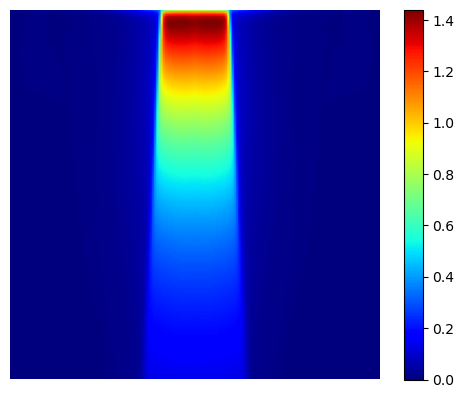

In [3]:
path ="/home/bolo/Downloads/10x10-10MV/RD1.2.752.243.1.1.20240927183310596.8800.73001.dcm"
path_ct = "/home/bolo/Downloads/10x10-10MV/CT1.2.752.243.1.1.20210112110104939.5560.87015.dcm"
ds = dcmread(path)
slice_idx = 92
ds_ref = ds.pixel_array * float(ds.DoseGridScaling)
ds_ref = np.transpose(ds_ref, (0, 1, 2))[:, 1:-1, 1:-1]
print(ds_ref.shape)

plt.imshow(ds_ref[slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.colorbar()
plt.show()

In [4]:
x_ct = 0.0 * np.expand_dims(np.ones(config.ct_array_shape), 0)
# x_ct[:, 50:120, 50:120, 65:120] = 0
# x_ct[:, 80:90, 80:90, 75:110] = 1000
y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = np.ones((1, config.number_of_cps), dtype=np.float32)
dose_layer = DoseEngine(config, 55, permute_ct=False, leafs_centered=True)
dose = dose_layer(torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device), ct_image=torch.tensor(x_ct, dtype=torch.float32, device=device)).detach().cpu().numpy()
# dose = np.transpose(dose, (0, 2, 1, 3))

(1, 185, 167, 167)


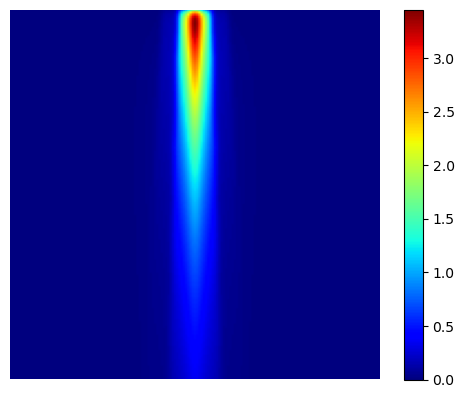

In [5]:
dose = dose / np.quantile(dose, 0.999) * np.quantile(ds_ref, 0.999)
print(dose.shape)

# plt.imshow(x_ct[0, :, :, 80], cmap='gray', vmin=-1, vmax=1)
plt.imshow(dose[0, slice_idx, :, :], cmap='jet', vmin=np.min(dose), vmax=np.max(dose)) #, alpha=0.5)
plt.axis('off')
plt.colorbar()
# plt.axis('off')
plt.show()

(1, 185, 167, 167)
(185, 167, 167)


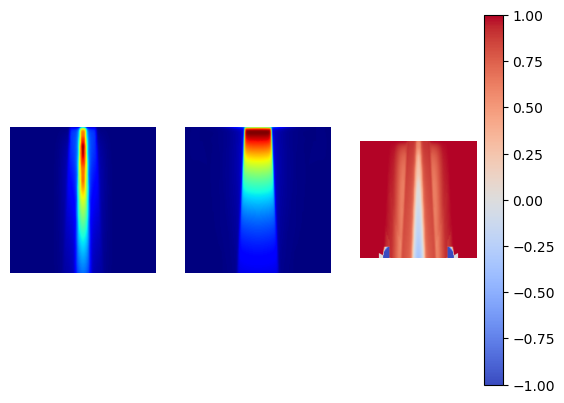

In [6]:
slice_idx = 84
print(dose.shape)
print(ds_ref.shape)

dose_plot = dose
plt.subplot(131)
plt.imshow(dose_plot[0, slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.subplot(132)
plt.imshow(ds_ref[slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.subplot(133)
plt.imshow((ds_ref[slice_idx, :, :] - dose_plot[0, slice_idx, :, :]) / (ds_ref[slice_idx, :, :] + 1e-10), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.axis('off')
plt.show()

preset=None ct_array_shape=(185, 167, 167) resolution=(3.0, 3.0, 3.0) field_size=(100, 100) downsampling_factor=(1, 1, 1) iso_center=(0.0, 150.0, 0.0) minimum_leaf_overlap=0.5 minimum_jaw_overlap=5.0 maximum_jaw_speed=2.25 maximum_leaf_speed=2.25 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 is_fff=True focal_spot_sigma=0.15 focus_to_collimator=49.7 oar_coeffs=(1.0, -0.0001, 2.5e-07) mlc_thickness=6.8 mlc_mu=0.7 dtype=torch.float32 device=device(type='cuda') number_of_leaf_pairs=5 tpr_20_10=0.72 mean_photon_energy_MeV=10.0 SID=1000.0 number_of_cps=1 starting_angle=0.0 clockwise=False


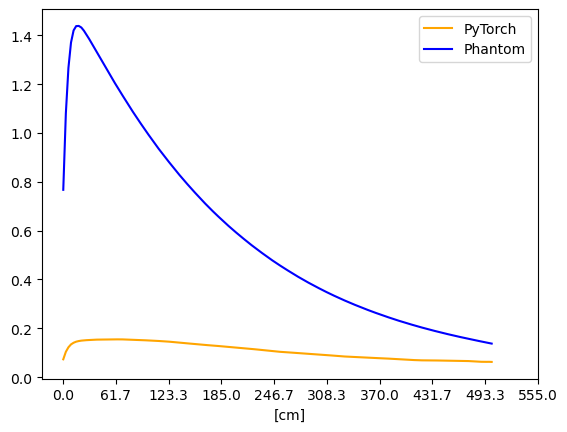

In [7]:
air_gap = 1

print(config)

slice_idx = 84
depth_index = 93

x = np.linspace(0, config.ct_array_shape[1], config.ct_array_shape[1])

# Create the plot
plt.plot(x, dose_plot[0, slice_idx, :, depth_index], label='PyTorch', color='orange')
plt.plot(x, ds_ref[slice_idx, :, depth_index], label='Phantom', color='blue')
plt.legend()

# Set x-ticks from 0 to 128, but label them as 0 to 26
num_ticks = 10
new_xticks = np.linspace(0, config.ct_array_shape[0], num_ticks)  # 27 points from 0 to 128
new_xtick_labels = np.round(np.linspace(0, config.ct_array_shape[0]*config.resolution[0], num_ticks), 1)  # Corresponding labels from 0 to 26

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()

preset=None ct_array_shape=(185, 167, 167) resolution=(3.0, 3.0, 3.0) field_size=(100, 100) downsampling_factor=(1, 1, 1) iso_center=(0.0, 150.0, 0.0) minimum_leaf_overlap=0.5 minimum_jaw_overlap=5.0 maximum_jaw_speed=2.25 maximum_leaf_speed=2.25 minimum_gantry_angle_speed=0.1 maximum_gantry_angle_speed=6.0 maximum_gantry_angle_speed_variation=0.75 minimum_dose_rate=50.0 maximum_dose_rate=600.0 is_fff=True focal_spot_sigma=0.15 focus_to_collimator=49.7 oar_coeffs=(1.0, -0.0001, 2.5e-07) mlc_thickness=6.8 mlc_mu=0.7 dtype=torch.float32 device=device(type='cuda') number_of_leaf_pairs=5 tpr_20_10=0.72 mean_photon_energy_MeV=10.0 SID=1000.0 number_of_cps=1 starting_angle=0.0 clockwise=False


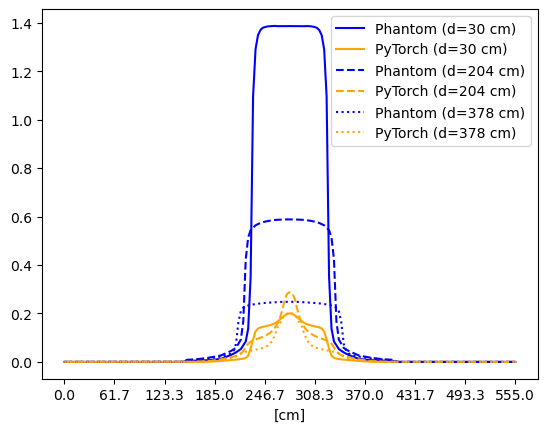

In [8]:
print(config)

x = np.linspace(0, config.ct_array_shape[0], config.ct_array_shape[0])

# Create the plot
slices = np.linspace(10, config.ct_array_shape[0], 3, endpoint=False).astype(int)
line_styles = ['-', '--', ':']
for i in range(len(slices)):
  plt.plot(x, ds_ref[:, slices[i], depth_index], label=f'Phantom (d={int(slices[i] * config.resolution[1])} cm)', color='blue', linestyle=line_styles[i])
  plt.plot(x, dose_plot[0, :, slices[i], depth_index], label=f'PyTorch (d={int(slices[i] * config.resolution[1])} cm)', color='orange', linestyle=line_styles[i])
plt.legend()

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[cm]')

# Show the plot
plt.show()